# 04 — Modeling

**Proyecto:** `ml_predict_income` · **Entradas:** `enigh2024_features_v2.parquet`, `split_upm.csv`,
`features_ocupados.json`, `features_no_ocupados.json`

---

## What this notebook does

| § | Output |
|---|---|
| 1 | Setup — reads the frozen split and the frozen feature lists |
| 2 | **Three-way split** (train / validation / test) and the data contract |
| 3 | A deliberately dumb baseline — the number every model must beat |
| 4 | Preprocessing pipelines, so the transform ships with the model |
| 5 | **Screening**: 10 model families at default settings, scored on validation |
| 6 | **Tuning**: random search → local grid, scored on validation · 6.1 how noisy one fold is |
| 7 | Weighted vs unweighted training |
| 8 | **Quantile models + conformal calibration** → the interval the product ships |
| 9 | Final evaluation on test: by segment, by income decile |
| 10 | Export: model bundle, feature contract, model card |
| 11 | **Ranked summary of every model evaluated** |

## Inherited, not re-decided here

- **The test partition comes from `split_upm.csv`.** It is *read*, never recomputed. A fresh
  `GroupShuffleSplit` here would silently invalidate every number in notebook 03 — the features were
  chosen using those exact training rows. §2 adds a validation set by subdividing train, leaving test
  byte-identical.
- **Features are frozen** in the two `features_*.json`: 10 for workers, 7 for non-workers, each with the
  question text that the form will use.
- **Target:** `log(ingreso_mensual)`, L1 / quantile objective → the prediction is the conditional
  **median**, back-transformed with `exp()`, **no smearing**.
- **Headline metrics:** MdAPE, share within ±20%, interval coverage. R² is a diagnostic, not a product number.
- **Outliers are kept.** Trimming at p99 caps predictions in a populated range; trimming at p99.9 moves
  MdAPE by 0.006 pp against 0.33 pp of run-to-run noise. The log + L1 target treatment already handles the
  right tail.
- **Two models**, routed by one question: *¿trabajaste el mes pasado?*

## The numbers to beat

Notebook 03, on test, with an untuned LightGBM:

| Segment | k | MdAPE | ±20% |
|---|---|---|---|
| Ocupados | 10 | 30.84% | 34.3% |
| No ocupados | 7 | 41.62% | 25.6% |

If tuning does not improve on these, the honest conclusion is that the features are the binding constraint,
not the model.


---
## 1. Setup

```bash
pip install pandas numpy matplotlib scikit-learn lightgbm xgboost joblib pyarrow
```


In [1]:
import json
import time
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (ExtraTreesRegressor, HistGradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge, SGDRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import (GridSearchCV, GroupKFold, GroupShuffleSplit,
                                     PredefinedSplit, RandomizedSearchCV)
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
for p in (FIG_DIR, MODEL_DIR):
    p.mkdir(parents=True, exist_ok=True)

print("pandas", pd.__version__, "| sklearn", __import__("sklearn").__version__,
      "| lightgbm", lgb.__version__, "| xgboost", xgb.__version__)

pandas 3.0.6 | sklearn 1.9.1 | lightgbm 4.7.0 | xgboost 3.2.0


In [2]:
# --------------------------------------------------------------- Parámetros
SEMILLA = 42
VAL_SIZE = 0.20             # proporción de los upm de train que forman validación
N_FOLDS = 3
N_SCREENING = 40_000        # submuestra de train para el tamizaje de §5
N_CANDIDATOS = 30           # candidatos de la búsqueda aleatoria
ALFAS = (0.10, 0.50, 0.90)  # cuantiles que ship-ea el producto
COBERTURA_OBJETIVO = 0.80   # del intervalo [q10, q90], corregido por conformal

SEGMENTOS = ["Ocupados", "No ocupados"]
ARCHIVOS_FEATURES = {"Ocupados": "features_ocupados.json",
                     "No ocupados": "features_no_ocupados.json"}


def es_numerica(s: pd.Series) -> bool:
    # pandas >= 3.0 entrega texto como `str` (Arrow), no `object`: preguntar por lo numérico.
    return pd.api.types.is_numeric_dtype(s)


def es_categorica(s: pd.Series) -> bool:
    return not es_numerica(s)

In [3]:
# --------------------------------------------------------------- Paleta
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
CMAP_SEQ = mpl.colors.LinearSegmentedColormap.from_list("azul", SEQ)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Segoe UI", "Helvetica", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.labelsize": 10, "axes.labelcolor": INK2, "axes.edgecolor": AXIS,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 8,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})
FMT_MILES = mpl.ticker.FuncFormatter(lambda x, _=None: f"{x:,.0f}")


def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.png")
    return fig


# --------------------------------------------------------------- Métricas
def wq(v, q, w):
    v, w = np.asarray(v, float), np.asarray(w, float)
    o = np.argsort(v); v, w = v[o], w[o]
    return float(np.interp(q, np.cumsum(w) / w.sum(), v))


def metricas(y_pesos, pred_pesos, w):
    """Todo ponderado por `factor`. Dos RMSE a propósito:

    - `RMSE` en pesos eleva al cuadrado un error que vive en una distribución lognormal, así que
      lo dominan unas decenas de filas del extremo alto. Es útil precisamente por eso: cuando
      discrepa del MdAPE, la discrepancia mide cuánta cola tiene el problema.
    - `RMSE_log` es el error cuadrático en la escala donde el modelo realmente aprende, y es el
      que sirve para comparar modelos entre sí sin que la cola decida el ranking."""
    pred = np.clip(pred_pesos, 1, None)
    err = np.abs(y_pesos - pred); ape = err / y_pesos
    res_log = np.log(y_pesos) - np.log(pred)
    return {
        "MdAPE": round(wq(ape, .5, w) * 100, 2),
        "pct_20": round(float(np.average(ape <= .20, weights=w)) * 100, 2),
        "MdAE": round(wq(err, .5, w), 0),
        "MAE": round(float(np.average(err, weights=w)), 0),
        "RMSE": round(float(np.sqrt(np.average((y_pesos - pred) ** 2, weights=w))), 0),
        "RMSE_log": round(float(np.sqrt(np.average(res_log ** 2, weights=w))), 4),
        "R2_log": round(float(
            1 - np.average(res_log ** 2, weights=w)
            / np.average((np.log(y_pesos) - np.average(np.log(y_pesos), weights=w)) ** 2, weights=w)), 4),
    }


# Bitácora única: toda evaluación de todo modelo se registra aquí y §11 la ordena.
REGISTRO = []


def registrar(segmento, modelo, etapa, conjunto, m, **extra):
    REGISTRO.append({"segmento": segmento, "modelo": modelo, "etapa": etapa,
                     "conjunto": conjunto, **m, **extra})
    return m

---
## 2. Data contract and the three-way split

### Why validation is carved out of train, not drawn afresh

`split_upm.csv` holds the two-way split that notebook 03 used to select the features. **The test partition
must not move.** If it did, the 17 features in the frozen lists would have been chosen using rows that now
sit in the test set, and every number downstream would be quietly optimistic.

So the validation set is carved out of **train**, grouped by `upm` like everything else:

| Partition | Share of `upm` | Used for |
|---|---|---|
| train | 64% | fitting every model |
| **validation** | 16% | comparing families, choosing hyper-parameters, calibrating the interval |
| test (holdout) | 20% | opened once, at the end, for the reported numbers |

The result is written to `split_upm_3way.csv` as a **new** file. `split_upm.csv` is left untouched so
notebook 03 stays reproducible.

### One honest caveat

Those validation rows were inside the training pool when notebook 03 ranked the features. So validation is
clean for *hyper-parameters* — which is what it is used for here — but not perfectly clean for *feature
selection*, which already happened. The test set is clean for both, which is why it remains the only
number reported as unbiased.

### A trade-off worth naming

Tuning against a single fixed validation set is exactly what was asked for and it is easy to reason about,
but it is noisier than k-fold CV: one partition, one draw. §6 therefore scores the search on the validation
set *and* reports a grouped 3-fold CV number for the winner, so the size of that noise is visible instead
of assumed.


In [4]:
df = pd.read_parquet(PROC_DIR / "enigh2024_features_v2.parquet")
split = pd.read_csv(PROC_DIR / "split_upm.csv", dtype={"upm": str})
df["upm"] = df["upm"].astype(str)
df = df.merge(split, on="upm", how="left", validate="many_to_one")
assert df["particion"].notna().all(), "Hay upm sin partición asignada en split_upm.csv"

FEATURES, CONTRATO = {}, {}
for seg, archivo in ARCHIVOS_FEATURES.items():
    spec = json.loads((PROC_DIR / archivo).read_text(encoding="utf-8"))
    FEATURES[seg] = spec["features"]
    CONTRATO[seg] = spec
    faltan = [c for c in spec["features"] if c not in df.columns]
    assert not faltan, f"{seg}: features que no existen en el parquet: {faltan}"

u_tr0 = set(df.loc[df.particion == "train", "upm"])
u_te = set(df.loc[df.particion == "test", "upm"])
assert not (u_tr0 & u_te), "El split leído tiene upm en ambas particiones"

# --- validación: 20% de los upm de train, sin tocar test
idx_train0 = np.where(df["particion"] == "train")[0]
i_tr, i_va = next(GroupShuffleSplit(1, test_size=VAL_SIZE, random_state=SEMILLA)
                  .split(idx_train0, groups=df["upm"].to_numpy()[idx_train0]))
df["particion3"] = df["particion"]
df.loc[df.index[idx_train0[i_va]], "particion3"] = "validation"

u3 = {p: set(g["upm"]) for p, g in df.groupby("particion3")}
assert not (u3["train"] & u3["validation"]), "upm en train y validation"
assert not (u3["train"] & u3["test"]) and not (u3["validation"] & u3["test"]), "fuga hacia test"
assert u3["test"] == u_te, "El conjunto de test cambió respecto a split_upm.csv"

(df[["upm", "particion3"]].drop_duplicates().sort_values("upm")
 .rename(columns={"particion3": "particion"})
 .to_csv(PROC_DIR / "split_upm_3way.csv", index=False))

resumen_split = pd.DataFrame([
    {"partición": p, "upm": len(u3[p]), "% upm": 100 * len(u3[p]) / df["upm"].nunique(),
     "personas": int((df.particion3 == p).sum()),
     "población": float(df.loc[df.particion3 == p, "factor"].sum())}
    for p in ["train", "validation", "test"]]).set_index("partición")
display(resumen_split.round(1))
print("guardado: split_upm_3way.csv  ·  split_upm.csv queda intacto (notebook 03 sigue reproducible)")
for seg in SEGMENTOS:
    print(f"  {seg:<12} k={len(FEATURES[seg])}  →  {FEATURES[seg]}")

,upm,% upm,personas,población
partición,,,,
train,6764,64.000,114723,"50,065,921.000"
validation,1691,16.000,28267,"11,625,444.000"
test,2114,20.000,36567,"15,453,177.000"


guardado: split_upm_3way.csv  ·  split_upm.csv queda intacto (notebook 03 sigue reproducible)
  Ocupados     k=10  →  ['horas_trabajadas', 'formalidad', 'cve_entidad', 'anios_escolaridad', 'sinco_grupo', 'posicion_ocupacion', 'es_jefe_hogar', 'sector_agrupado', 'es_mujer', 'tam_empresa_grupo']
  No ocupados  k=7  →  ['actividad_no_ocupado', 'es_jefe_hogar', 'anios_escolaridad', 'edad', 'cve_entidad', 'integrantes_hogar', 'situacion_conyugal']


In [5]:
TARGET = "ingreso_mensual"
datos = {}
for seg in SEGMENTOS:
    sub = df[df.segmento == seg].reset_index(drop=True)
    cols = FEATURES[seg]
    X = sub[cols].copy()
    cat = [c for c in cols if es_categorica(X[c])]
    num = [c for c in cols if c not in cat]
    for c in cat:
        X[c] = X[c].astype(str)
    for c in num:
        X[c] = pd.to_numeric(X[c]).astype("float64")   # sin coerce: que truene si algo no cuadra
    assert not [c for c in cols if X[c].isna().all()], f"{seg}: columna vacía tras el tipado"

    p3 = sub["particion3"].to_numpy()
    datos[seg] = dict(X=X, cat=cat, num=num,
                      y=np.log(sub[TARGET].clip(lower=1)).to_numpy(),
                      y_pesos=sub[TARGET].to_numpy(),
                      w=sub["factor"].to_numpy(),
                      upm=sub["upm"].to_numpy(),
                      tr=(p3 == "train"), va=(p3 == "validation"), te=(p3 == "test"))
    d = datos[seg]
    print(f"{seg:<12} train={d['tr'].sum():>7,}  validation={d['va'].sum():>6,}  "
          f"test={d['te'].sum():>6,}   num={len(num)} cat={len(cat)}")


def idx(seg, parte):
    return np.where(datos[seg][parte])[0]


def evaluar(seg, pred_log, parte):
    """Métricas ponderadas de una predicción en log sobre la partición indicada."""
    d, i = datos[seg], idx(seg, parte)
    return metricas(d["y_pesos"][i], np.exp(pred_log), d["w"][i])

Ocupados     train= 88,980  validation=21,763  test=28,428   num=4 cat=6
No ocupados  train= 25,743  validation= 6,504  test= 8,139   num=4 cat=3


---
## 3. The baseline

Before any model: what does a lookup table get? Weighted median income by
(years of schooling, banded) × (state), computed on train, applied to test. No learning, no tuning, five
lines of code.

Every model below is reported against this. A model that cannot clearly beat a pivot table has not earned
its complexity — and stating the baseline up front is what keeps the comparison honest later, when the
gradient boosting numbers look impressive in isolation.


In [6]:
BINS_ESC = [-1, 5, 8, 11, 14, 16, 99]   # sin primaria, primaria, secundaria, media, licenciatura, posgrado


def baseline_celdas(seg, min_celda=30):
    """Se construye SÓLO con train y se evalúa en validation y en test."""
    d = datos[seg]
    celda = (pd.cut(d["X"]["anios_escolaridad"], BINS_ESC).astype(str)
             + " | " + d["X"]["cve_entidad"].astype(str))
    aux = pd.DataFrame({"celda": celda, "y": d["y_pesos"], "w": d["w"], "tr": d["tr"]})
    tabla = {k: wq(g["y"].to_numpy(), .5, g["w"].to_numpy())
             for k, g in aux[aux.tr].groupby("celda") if len(g) >= min_celda}
    mediana_global = wq(d["y_pesos"][d["tr"]], .5, d["w"][d["tr"]])
    pred = celda.map(tabla).fillna(mediana_global).to_numpy()
    return {parte: metricas(d["y_pesos"][idx(seg, parte)], pred[idx(seg, parte)],
                            d["w"][idx(seg, parte)])
            for parte in ("va", "te")}, len(tabla)


BASELINE = {}
for seg in SEGMENTOS:
    BASELINE[seg], n_celdas = baseline_celdas(seg)
    for parte, nombre in [("va", "validation"), ("te", "test")]:
        registrar(seg, "Baseline (tabla dinámica)", "baseline", nombre,
                  BASELINE[seg][parte], k=2, segundos=0.0)
    print(f"{seg:<12} tabla de {n_celdas:>3} celdas  ·  "
          f"validation MdAPE={BASELINE[seg]['va']['MdAPE']:.2f}%  "
          f"test MdAPE={BASELINE[seg]['te']['MdAPE']:.2f}%  RMSE=${BASELINE[seg]['te']['RMSE']:,.0f}")

Ocupados     tabla de 192 celdas  ·  validation MdAPE=37.38%  test MdAPE=38.57%  RMSE=$14,227
No ocupados  tabla de 181 celdas  ·  validation MdAPE=57.82%  test MdAPE=59.61%  RMSE=$11,066


---
## 4. Preprocessing

Three modes, because the families genuinely need different inputs:

| Mode | For | What it does |
|---|---|---|
| `nativo` | LightGBM, XGBoost, HistGradientBoosting | keeps a DataFrame and casts the categoricals to pandas `category`, so the booster splits on **sets of categories** rather than on an invented numeric order |
| `ordinal` | decision tree, random forest, extra trees | integer codes + median imputation — scikit-learn's forests take a numeric matrix |
| `onehot` | ridge, elastic net, SGD, MLP | one-hot + standardisation, rare levels folded together |

The `nativo` mode matters more than it looks. Feeding ordinal codes to a booster tells it that state 07 sits
between 06 and 08, which is false and costs real accuracy; it is also how a pipeline quietly underperforms
the quick experiment that preceded it.

All three live inside a `Pipeline`, so the fitted transform travels with the fitted model. An exported model
whose preprocessing lives in a notebook cell is a model that will be served wrong.

Unknown categories degrade instead of raising: `handle_unknown` on the encoders, and unseen levels become
`NaN` in `nativo` mode, which the boosters route natively.


In [7]:
from sklearn.base import BaseEstimator, TransformerMixin, clone


class ACategorias(BaseEstimator, TransformerMixin):
    """Deja el DataFrame intacto pero con las categóricas como dtype `category`.

    Las categorías se fijan en fit: un nivel no visto se vuelve NaN en transform, que es
    exactamente lo que LightGBM / XGBoost / HistGradientBoosting saben manejar."""

    def __init__(self, cat=()):
        self.cat = cat          # se guarda tal cual: `clone` exige que __init__ no modifique params

    def fit(self, X, y=None):
        self.cat_ = list(self.cat)
        self.categorias_ = {c: pd.Index(sorted(X[c].astype(str).dropna().unique()))
                            for c in self.cat_}
        self.feature_names_in_ = np.asarray(X.columns)
        return self

    def transform(self, X):
        X = X.copy()
        for c in self.cat_:
            X[c] = pd.Categorical(X[c].astype(str), categories=self.categorias_[c])
        return X


def preprocesador(seg, tipo):
    d = datos[seg]
    if tipo == "nativo":
        return ACategorias(d["cat"])
    if tipo == "ordinal":
        return ColumnTransformer([
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                                   encoded_missing_value=-1), d["cat"]),
            ("num", SimpleImputer(strategy="median"), d["num"]),
        ], verbose_feature_names_out=False)
    if tipo == "onehot":
        return ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30,
                                  sparse_output=False), d["cat"]),
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("sc", StandardScaler())]), d["num"]),
        ], verbose_feature_names_out=False)
    raise ValueError(tipo)


for seg in SEGMENTOS:
    Xtr = datos[seg]["X"].loc[datos[seg]["tr"]]
    nat = preprocesador(seg, "nativo").fit(Xtr).transform(Xtr.head(5))
    oh = preprocesador(seg, "onehot").fit(Xtr).transform(Xtr.head(5))
    print(f"{seg:<12} nativo → {nat.shape[1]} columnas "
          f"({sum(str(nat[c].dtype) == 'category' for c in nat.columns)} categóricas) | "
          f"one-hot → {oh.shape[1]} columnas")

Ocupados     nativo → 10 columnas (6 categóricas) | one-hot → 68 columnas
No ocupados  nativo → 7 columnas (3 categóricas) | one-hot → 48 columnas


---
## 5. Screening — ten model families

A first pass at default-ish settings: fitted on (a subsample of) **train**, scored on the **validation**
set from §2. The test set is not involved and will not be until §9.

This is a screening pass, not a tournament. Its job is to answer one question — *does any family behave
differently enough to be worth the tuning budget?* — and to make the answer visible instead of assumed.
Tuning goes to the top two, because on 110k rows of mixed tabular data with 10 features, the ranking here
is rarely overturned by hyper-parameters.

Two families are included precisely because they are expected to lose: a single decision tree, and a linear
model on one-hot inputs. If the ensembles cannot beat those clearly, the extra complexity is not paying
for itself.

**One constraint on who gets tuned.** What ships is an interval, so the family must be able to fit quantile
losses — LightGBM, XGBoost and HistGradientBoosting can; random forests and extra trees cannot without
bolting on a separate mechanism. A family that wins the point-estimate screening but cannot produce the
deliverable is not really a winner, and shipping its quantiles from a different family would mean the model
card describes something other than what runs. So the tuning budget goes to the best **quantile-capable**
families; the rest are still screened and reported, as the reference they are.


In [8]:
def mdape_desde_log(y_log, pred_log):
    """MdAPE sin salir del espacio log: |exp(ŷ)-exp(y)|/exp(y) = |exp(ŷ-y)-1|."""
    return float(np.median(np.abs(np.exp(np.asarray(pred_log) - np.asarray(y_log)) - 1)))


SCORER = make_scorer(lambda yt, yp: -mdape_desde_log(yt, yp), greater_is_better=True)

FAMILIAS = [
    ("Ridge",                "onehot",  lambda: Ridge(alpha=1.0)),
    ("ElasticNet",           "onehot",  lambda: ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=3000)),
    ("SGD (Huber)",          "onehot",  lambda: SGDRegressor(loss="huber", epsilon=0.1, max_iter=1500,
                                                             random_state=0)),
    ("Red neuronal (MLP)",   "onehot",  lambda: MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=60,
                                                             early_stopping=True, random_state=0)),
    ("Árbol de decisión",    "ordinal", lambda: DecisionTreeRegressor(max_depth=12, min_samples_leaf=50,
                                                                      random_state=0)),
    ("Random Forest",        "ordinal", lambda: RandomForestRegressor(n_estimators=150, min_samples_leaf=20,
                                                                      n_jobs=-1, random_state=0)),
    ("Extra Trees",          "ordinal", lambda: ExtraTreesRegressor(n_estimators=150, min_samples_leaf=20,
                                                                    n_jobs=-1, random_state=0)),
    ("HistGradientBoosting", "nativo",  lambda: HistGradientBoostingRegressor(
        loss="absolute_error", max_iter=300, categorical_features="from_dtype", random_state=0)),
    ("LightGBM",             "nativo",  lambda: lgb.LGBMRegressor(
        objective="regression_l1", n_estimators=300, learning_rate=.08, num_leaves=48,
        verbose=-1, n_jobs=-1, random_state=0)),
    ("XGBoost",              "nativo",  lambda: xgb.XGBRegressor(
        objective="reg:absoluteerror", n_estimators=300, learning_rate=.08, max_depth=6,
        tree_method="hist", enable_categorical=True, n_jobs=-1, random_state=0)),
]
print(f"{len(FAMILIAS)} familias a tamizar × {len(SEGMENTOS)} segmentos")

10 familias a tamizar × 2 segmentos


In [9]:
def construir(seg, tipo, estimador):
    return Pipeline([("prep", preprocesador(seg, tipo)), ("modelo", estimador)])


tamizaje = []
for seg in SEGMENTOS:
    d = datos[seg]
    i_fit, i_val = idx(seg, "tr"), idx(seg, "va")
    if len(i_fit) > N_SCREENING:
        i_fit = np.random.RandomState(SEMILLA).choice(i_fit, N_SCREENING, replace=False)
    print(f"\n=== {seg} · ajuste en {len(i_fit):,} filas de train, "
          f"validación en {len(i_val):,} ===")
    for nombre, tipo, hacer in FAMILIAS:
        t0 = time.time()
        pipe = construir(seg, tipo, hacer())
        pipe.fit(d["X"].iloc[i_fit], d["y"][i_fit])
        m = evaluar(seg, pipe.predict(d["X"].iloc[i_val]), "va")
        secs = round(time.time() - t0, 1)
        tamizaje.append({"segmento": seg, "familia": nombre, "preproc": tipo,
                         "segundos": secs, **m})
        registrar(seg, nombre, "tamizaje (defaults)", "validation", m,
                  k=len(FEATURES[seg]), segundos=secs)
        print(f"  {nombre:<22} MdAPE={m['MdAPE']:>6.2f}%  RMSE=${m['RMSE']:>9,.0f}  "
              f"RMSE_log={m['RMSE_log']:.3f}  ±20%={m['pct_20']:>5.2f}%  ({secs:>5.1f}s)")

tamizaje = pd.DataFrame(tamizaje)
tamizaje.sort_values(["segmento", "MdAPE"]).reset_index(drop=True)


=== Ocupados · ajuste en 40,000 filas de train, validación en 21,763 ===
  Ridge                  MdAPE= 33.95%  RMSE=$   15,717  RMSE_log=0.730  ±20%=31.04%  (  0.4s)
  ElasticNet             MdAPE= 34.32%  RMSE=$   16,015  RMSE_log=0.746  ±20%=30.15%  (  0.7s)
  SGD (Huber)            MdAPE= 34.27%  RMSE=$   16,253  RMSE_log=0.777  ±20%=30.85%  (  0.5s)
  Red neuronal (MLP)     MdAPE= 32.02%  RMSE=$   15,403  RMSE_log=0.706  ±20%=32.71%  (  3.2s)
  Árbol de decisión      MdAPE= 33.24%  RMSE=$   15,651  RMSE_log=0.732  ±20%=31.66%  (  0.2s)
  Random Forest          MdAPE= 32.09%  RMSE=$   15,541  RMSE_log=0.714  ±20%=33.66%  (  2.0s)
  Extra Trees            MdAPE= 32.06%  RMSE=$   15,635  RMSE_log=0.713  ±20%=33.69%  (  1.4s)
  HistGradientBoosting   MdAPE= 30.56%  RMSE=$   15,374  RMSE_log=0.705  ±20%=35.25%  (  1.0s)
  LightGBM               MdAPE= 30.74%  RMSE=$   15,221  RMSE_log=0.704  ±20%=34.77%  (  1.2s)
  XGBoost                MdAPE= 30.35%  RMSE=$   15,154  RMSE_log=0.706

,segmento,familia,preproc,segundos,MdAPE,pct_20,MdAE,MAE,RMSE,RMSE_log,R2_log
0,No ocupados,HistGradientBoosting,nativo,0.400,41.450,26.310,"1,422.000","3,394.000","8,440.000",0.874,0.462
1,No ocupados,LightGBM,nativo,0.600,41.920,26.430,"1,419.000","3,399.000","8,457.000",0.875,0.461
2,No ocupados,XGBoost,nativo,1.600,42.270,25.840,"1,426.000","3,401.000","8,442.000",0.873,0.464
3,No ocupados,Extra Trees,ordinal,0.600,42.390,24.260,"1,498.000","3,444.000","8,453.000",0.873,0.463
4,No ocupados,Random Forest,ordinal,0.800,42.750,25.390,"1,491.000","3,438.000","8,468.000",0.875,0.462
5,No ocupados,Árbol de decisión,ordinal,0.100,43.380,25.260,"1,525.000","3,490.000","8,500.000",0.891,0.441
6,No ocupados,Red neuronal (MLP),onehot,2.500,45.040,24.370,"1,460.000","3,481.000","8,448.000",0.878,0.458
7,No ocupados,Ridge,onehot,0.100,47.020,20.850,"1,599.000","3,602.000","8,613.000",0.900,0.430
8,No ocupados,ElasticNet,onehot,0.200,47.400,21.580,"1,610.000","3,605.000","8,642.000",0.903,0.425
9,No ocupados,SGD (Huber),onehot,0.200,48.690,21.020,"1,679.000","3,673.000","8,733.000",0.929,0.392


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.
findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


Ocupados     mejor absoluto: XGBoost (30.35%)
             a tunear: ['XGBoost', 'HistGradientBoosting'] (30.35%, 30.56%)
No ocupados  mejor absoluto: HistGradientBoosting (41.45%)
             a tunear: ['HistGradientBoosting', 'LightGBM'] (41.45%, 41.92%)


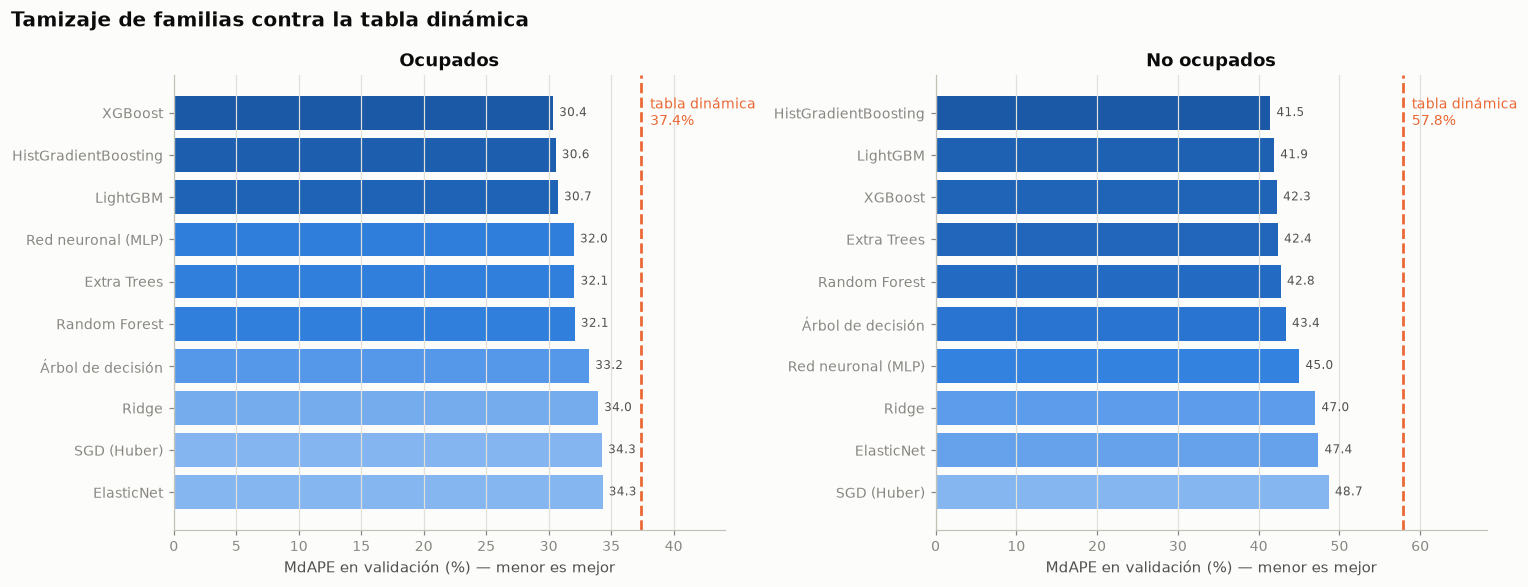

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, seg in zip(axes, SEGMENTOS):
    t = tamizaje[tamizaje.segmento == seg].sort_values("MdAPE", ascending=False)
    norm = 1 - (t["MdAPE"] - t["MdAPE"].min()) / (t["MdAPE"].max() - t["MdAPE"].min() + 1e-9)
    ax.barh(np.arange(len(t)), t["MdAPE"], color=CMAP_SEQ(.25 + .60 * norm.values))
    ax.set_yticks(np.arange(len(t))); ax.set_yticklabels(t["familia"])
    base_va = BASELINE[seg]["va"]["MdAPE"]
    ax.axvline(base_va, color=SERIES[1], linewidth=1.8, linestyle="--")
    ax.annotate(f"tabla dinámica\n{base_va:.1f}%", (base_va, len(t) - .6),
                xytext=(6, 0), textcoords="offset points", color=SERIES[1], fontsize=9, va="top")
    for i, v in enumerate(t["MdAPE"]):
        ax.annotate(f"{v:.1f}", (v, i), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8, color=INK2)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, max(t["MdAPE"].max(), base_va) * 1.18)
    ax.set_xlabel("MdAPE en validación (%) — menor es mejor")
    ax.set_title(seg)
fig.suptitle("Tamizaje de familias contra la tabla dinámica", x=0.01, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "04_tamizaje")

# Familias capaces de ajustar pérdidas cuantil: son las únicas que pueden entregar el intervalo
FAMILIAS_CUANTIL = {"LightGBM", "XGBoost", "HistGradientBoosting"}

FINALISTAS = {}
for seg in SEGMENTOS:
    t = tamizaje[tamizaje.segmento == seg].sort_values("MdAPE")
    mejor_absoluto = t.iloc[0]
    FINALISTAS[seg] = t[t.familia.isin(FAMILIAS_CUANTIL)].head(2)["familia"].tolist()
    print(f"{seg:<12} mejor absoluto: {mejor_absoluto.familia} ({mejor_absoluto.MdAPE:.2f}%)"
          f"{'' if mejor_absoluto.familia in FAMILIAS_CUANTIL else '  ← no soporta cuantiles, no se tunea'}")
    print(f"             a tunear: {FINALISTAS[seg]} "
          f"({', '.join(f'{r.MdAPE:.2f}%' for _, r in t[t.familia.isin(FINALISTAS[seg])].iterrows())})")

---
## 6. Tuning — random search, then a local grid, both scored on validation

Two stages:

1. **`RandomizedSearchCV`** over a wide space, with a `PredefinedSplit` that fits every candidate on
   **train** and scores it on **validation** — the three-way split doing exactly the job it was built for.
2. **`GridSearchCV`** on a small neighbourhood of the winner: one step either side on the parameters that
   moved the score. Deliberately tiny.

Two implementation notes that matter:

- **`refit=False`** on both searches. With a single validation fold, scikit-learn would otherwise refit the
  winner on train **and** validation — which would contaminate the set used in §8 to calibrate the interval.
  The searches only choose parameters; the fitting happens explicitly on train afterwards.
- A single validation fold means each candidate costs **one** fit rather than three, so the budget buys more
  candidates. That is the compensation for the noisier estimate, not a free lunch: §6.1 measures how much
  noise a single fold actually carries.

A caveat worth stating rather than hiding: a grid over a neighbourhood the random search already explored
usually buys very little. It is kept because it documents the local shape of the optimum — if the grid finds
something materially better, the random search was under-sampled, and that is itself information.

**Scoring is MdAPE**, computed in log space as `|exp(ŷ−y) − 1|`, so the search optimises the metric the
product reports rather than a convenient proxy. Selection here is unweighted; every number reported to a
human is weighted.


In [11]:
ESPACIOS = {
    "LightGBM": {
        "modelo__num_leaves": [15, 31, 48, 63, 96, 127],
        "modelo__learning_rate": [0.02, 0.04, 0.06, 0.08, 0.12],
        "modelo__n_estimators": [300, 500, 800, 1200],
        "modelo__min_child_samples": [20, 40, 60, 100],
        "modelo__subsample": [0.7, 0.8, 0.9, 1.0],
        "modelo__colsample_bytree": [0.6, 0.8, 1.0],
        "modelo__reg_lambda": [0, 1, 5, 20],
    },
    "XGBoost": {
        "modelo__max_depth": [4, 6, 8, 10],
        "modelo__learning_rate": [0.02, 0.04, 0.06, 0.08, 0.12],
        "modelo__n_estimators": [300, 500, 800, 1200],
        "modelo__min_child_weight": [1, 5, 20, 50],
        "modelo__subsample": [0.7, 0.8, 0.9, 1.0],
        "modelo__colsample_bytree": [0.6, 0.8, 1.0],
        "modelo__reg_lambda": [0.5, 1, 5, 20],
    },
    "HistGradientBoosting": {
        "modelo__max_leaf_nodes": [15, 31, 63, 127],
        "modelo__learning_rate": [0.02, 0.04, 0.08, 0.12],
        "modelo__max_iter": [300, 500, 800],
        "modelo__min_samples_leaf": [20, 40, 80],
        "modelo__l2_regularization": [0, 0.1, 1, 10],
    },
    "Random Forest": {
        "modelo__n_estimators": [200, 400],
        "modelo__max_depth": [None, 16, 24],
        "modelo__min_samples_leaf": [5, 10, 20, 40],
        "modelo__max_features": [0.4, 0.6, 0.8, 1.0],
    },
    "Extra Trees": {
        "modelo__n_estimators": [200, 400],
        "modelo__max_depth": [None, 16, 24],
        "modelo__min_samples_leaf": [5, 10, 20, 40],
        "modelo__max_features": [0.4, 0.6, 0.8, 1.0],
    },
}
CONSTRUCTOR = {n: (t, f) for n, t, f in FAMILIAS}

In [12]:
def datos_tuning(seg):
    """Índices train+validation y el PredefinedSplit que ajusta en train y puntúa en validation."""
    i_tr, i_va = idx(seg, "tr"), idx(seg, "va")
    orden = np.concatenate([i_tr, i_va])
    fold = np.concatenate([np.full(len(i_tr), -1),     # -1 = siempre en entrenamiento
                           np.zeros(len(i_va), dtype=int)])
    return orden, PredefinedSplit(fold)


def buscar(seg, familia, n_iter=N_CANDIDATOS):
    d = datos[seg]
    orden, ps = datos_tuning(seg)
    tipo, hacer = CONSTRUCTOR[familia]
    t0 = time.time()
    rs = RandomizedSearchCV(construir(seg, tipo, hacer()), ESPACIOS[familia], n_iter=n_iter,
                            cv=ps, scoring=SCORER, random_state=SEMILLA, n_jobs=1,
                            refit=False, error_score="raise")
    rs.fit(d["X"].iloc[orden], d["y"][orden])
    return rs, time.time() - t0


def ajustar(seg, familia, params, ponderar=False):
    """Construye el pipeline con esos parámetros y lo ajusta SÓLO en train."""
    d = datos[seg]
    i_tr = idx(seg, "tr")
    tipo, hacer = CONSTRUCTOR[familia]
    pipe = construir(seg, tipo, hacer()).set_params(**params)
    kw = {"modelo__sample_weight": d["w"][i_tr]} if ponderar else {}
    pipe.fit(d["X"].iloc[i_tr], d["y"][i_tr], **kw)
    return pipe


# Los lineales y el árbol suelto no tienen espacio definido; si ninguno lo tiene, se tunea LightGBM.
PARA_TUNEAR = {seg: [f for f in FINALISTAS[seg] if f in ESPACIOS] or ["LightGBM"]
               for seg in SEGMENTOS}
print("A tunear:", PARA_TUNEAR)

busquedas, resumen_tuning = {}, []
for seg in SEGMENTOS:
    for familia in PARA_TUNEAR[seg]:
        rs, secs = buscar(seg, familia)
        busquedas[(seg, familia)] = rs
        pipe = ajustar(seg, familia, rs.best_params_)
        m = evaluar(seg, pipe.predict(datos[seg]["X"].iloc[idx(seg, "va")]), "va")
        registrar(seg, familia, "tuneado (random)", "validation", m,
                  k=len(FEATURES[seg]), segundos=round(secs, 0))
        fila_t = tamizaje[(tamizaje.segmento == seg) & (tamizaje.familia == familia)]["MdAPE"]
        resumen_tuning.append({"segmento": seg, "familia": familia, "etapa": "random",
                               "MdAPE_val": m["MdAPE"], "RMSE_log": m["RMSE_log"],
                               "MdAPE_defaults": float(fila_t.iloc[0]) if len(fila_t) else np.nan,
                               "segundos": round(secs, 0)})
        print(f"{seg:<12} {familia:<22} MdAPE_val={m['MdAPE']:.2f}%  "
              f"(defaults {float(fila_t.iloc[0]):.2f}%)  ({secs:.0f}s)")
        print(f"    mejores params: "
              f"{ {k.replace('modelo__', ''): v for k, v in rs.best_params_.items()} }")
pd.DataFrame(resumen_tuning)

A tunear: {'Ocupados': ['XGBoost', 'HistGradientBoosting'], 'No ocupados': ['HistGradientBoosting', 'LightGBM']}
Ocupados     XGBoost                MdAPE_val=29.70%  (defaults 30.35%)  (342s)
    mejores params: {'subsample': 0.8, 'reg_lambda': 0.5, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.02, 'colsample_bytree': 0.6}
Ocupados     HistGradientBoosting   MdAPE_val=29.84%  (defaults 30.56%)  (94s)
    mejores params: {'min_samples_leaf': 40, 'max_leaf_nodes': 127, 'max_iter': 300, 'learning_rate': 0.08, 'l2_regularization': 10}
No ocupados  HistGradientBoosting   MdAPE_val=41.56%  (defaults 41.45%)  (34s)
    mejores params: {'min_samples_leaf': 80, 'max_leaf_nodes': 31, 'max_iter': 800, 'learning_rate': 0.12, 'l2_regularization': 0.1}
No ocupados  LightGBM               MdAPE_val=41.81%  (defaults 41.92%)  (58s)
    mejores params: {'subsample': 0.8, 'reg_lambda': 0, 'num_leaves': 48, 'n_estimators': 500, 'min_child_samples': 60, 'learning_rate': 

,segmento,familia,etapa,MdAPE_val,RMSE_log,MdAPE_defaults,segundos
0,Ocupados,XGBoost,random,29.700,0.701,30.350,342.000
1,Ocupados,HistGradientBoosting,random,29.840,0.702,30.560,94.000
2,No ocupados,HistGradientBoosting,random,41.560,0.874,41.450,34.000
3,No ocupados,LightGBM,random,41.810,0.871,41.920,58.000


In [13]:
def rejilla_local(seg, familia, mejores):
    """Un paso a cada lado del ganador, sólo en los parámetros con escala numérica."""
    espacio = ESPACIOS[familia]
    rejilla = {}
    for k, v in mejores.items():
        opciones = espacio.get(k, [])
        if len(opciones) < 2 or not all(isinstance(o, (int, float)) for o in opciones):
            continue
        orden = sorted(opciones)
        i = orden.index(v)
        rejilla[k] = sorted({orden[max(i - 1, 0)], v, orden[min(i + 1, len(orden) - 1)]})
    # se refinan a lo más 2 parámetros para que la rejilla no explote
    claves = sorted(rejilla, key=lambda k: -len(rejilla[k]))[:2]
    rejilla = {k: rejilla[k] for k in claves}
    for k, v in mejores.items():
        if k not in rejilla:
            rejilla[k] = [v]
    return rejilla


finales = {}
for seg in SEGMENTOS:
    mejor_familia = min(PARA_TUNEAR[seg],
                        key=lambda f: next((r["MdAPE_val"] for r in resumen_tuning
                                            if r["segmento"] == seg and r["familia"] == f), 1e9))
    rs = busquedas[(seg, mejor_familia)]
    rejilla = rejilla_local(seg, mejor_familia, rs.best_params_)
    n_combos = int(np.prod([len(v) for v in rejilla.values()]))
    d = datos[seg]
    orden, ps = datos_tuning(seg)
    tipo, hacer = CONSTRUCTOR[mejor_familia]

    t0 = time.time()
    gs = GridSearchCV(construir(seg, tipo, hacer()), rejilla, cv=ps, scoring=SCORER,
                      n_jobs=1, refit=False)
    gs.fit(d["X"].iloc[orden], d["y"][orden])
    secs = time.time() - t0

    gana_rejilla = gs.best_score_ > rs.best_score_
    params = gs.best_params_ if gana_rejilla else rs.best_params_
    pipe = ajustar(seg, mejor_familia, params)
    m = evaluar(seg, pipe.predict(d["X"].iloc[idx(seg, "va")]), "va")
    registrar(seg, mejor_familia, "tuneado (random+grid)", "validation", m,
              k=len(FEATURES[seg]), segundos=round(secs, 0))

    finales[seg] = {"familia": mejor_familia, "params": params, "estimador": pipe,
                    "MdAPE_val": m["MdAPE"], "etapa_ganadora": "grid" if gana_rejilla else "random"}
    resumen_tuning.append({"segmento": seg, "familia": mejor_familia, "etapa": f"grid ({n_combos} combos)",
                           "MdAPE_val": round(-gs.best_score_ * 100, 3), "RMSE_log": m["RMSE_log"],
                           "MdAPE_defaults": np.nan, "segundos": round(secs, 0)})
    print(f"{seg:<12} {mejor_familia:<22} random={-rs.best_score_ * 100:.3f}%  "
          f"grid={-gs.best_score_ * 100:.3f}%  → gana {finales[seg]['etapa_ganadora']}  ({secs:.0f}s)")
    print(f"             ↑ criterio de la búsqueda: MdAPE SIN ponderar. El mismo modelo, "
          f"ponderado, da {m['MdAPE']:.2f}% — es la cifra que va a la bitácora.")

display(pd.DataFrame(resumen_tuning))

Ocupados     XGBoost                random=30.772%  grid=30.719%  → gana grid  (39s)
             ↑ criterio de la búsqueda: MdAPE SIN ponderar. El mismo modelo, ponderado, da 29.64% — es la cifra que va a la bitácora.
No ocupados  HistGradientBoosting   random=42.655%  grid=42.655%  → gana random  (3s)
             ↑ criterio de la búsqueda: MdAPE SIN ponderar. El mismo modelo, ponderado, da 41.56% — es la cifra que va a la bitácora.


,segmento,familia,etapa,MdAPE_val,RMSE_log,MdAPE_defaults,segundos
0,Ocupados,XGBoost,random,29.700,0.701,30.350,342.000
1,Ocupados,HistGradientBoosting,random,29.840,0.702,30.560,94.000
2,No ocupados,HistGradientBoosting,random,41.560,0.874,41.450,34.000
3,No ocupados,LightGBM,random,41.810,0.871,41.920,58.000
4,Ocupados,XGBoost,grid (6 combos),30.719,0.701,NaN,39.000
5,No ocupados,HistGradientBoosting,grid (9 combos),42.655,0.874,NaN,3.000


### 6.1 How much can a single validation fold be trusted?

The tuned configuration is re-scored with grouped 3-fold CV **inside train**, which never touches
validation. The spread across folds is the honest error bar on every number in §5 and §6: differences
between models smaller than that spread are not differences at all.

Read the **spread**, not the level. Each CV fold trains on two thirds of train, so its MdAPE is mildly
pessimistic compared with the validation number, which comes from a model fitted on all of train. The
comparison that matters is `cv_max − cv_min`.


In [14]:
ruido = []
for seg in SEGMENTOS:
    d = datos[seg]
    i_tr = idx(seg, "tr")
    scores = []
    for a, b in GroupKFold(n_splits=N_FOLDS).split(i_tr, groups=d["upm"][i_tr]):
        tipo, hacer = CONSTRUCTOR[finales[seg]["familia"]]
        pipe = construir(seg, tipo, hacer()).set_params(**finales[seg]["params"])
        pipe.fit(d["X"].iloc[i_tr[a]], d["y"][i_tr[a]])
        pred = np.exp(pipe.predict(d["X"].iloc[i_tr[b]]))
        # ponderado, igual que todo lo demás: si no, no es comparable con MdAPE_validation
        scores.append(metricas(d["y_pesos"][i_tr[b]], pred, d["w"][i_tr[b]])["MdAPE"])
    ruido.append({"segmento": seg, "familia": finales[seg]["familia"],
                  "MdAPE_validation": finales[seg]["MdAPE_val"],
                  "MdAPE_cv_media": round(float(np.mean(scores)), 2),
                  "cv_min": round(min(scores), 2), "cv_max": round(max(scores), 2),
                  "rango_cv_pp": round(max(scores) - min(scores), 2)})
display(pd.DataFrame(ruido))
print("Regla de lectura: si dos modelos difieren por menos que `rango_cv_pp`, están empatados.")

,segmento,familia,MdAPE_validation,MdAPE_cv_media,cv_min,cv_max,rango_cv_pp
0,Ocupados,XGBoost,29.640,30.660,30.350,31.240,0.890
1,No ocupados,HistGradientBoosting,41.560,42.710,41.820,43.510,1.690


Regla de lectura: si dos modelos difieren por menos que `rango_cv_pp`, están empatados.


---
## 7. Weighted or unweighted training?

`factor` is an expansion weight: each row stands for between 4 and ~7,000 people. Training weighted
estimates the relationship in the *population*; training unweighted estimates it in the *sample*, which
over-represents whoever ENIGH sampled more densely.

There is no universal answer, so it is measured on the internal validation split with the tuned
configuration. Evaluation is weighted either way — that part is not optional, because an unweighted test
metric describes the sample and nobody wants to know about the sample.


In [15]:
comparacion_peso = []
for seg in SEGMENTOS:
    d = datos[seg]
    for etiqueta, pond in [("sin ponderar", False), ("ponderado por factor", True)]:
        pipe = ajustar(seg, finales[seg]["familia"], finales[seg]["params"], ponderar=pond)
        m = evaluar(seg, pipe.predict(d["X"].iloc[idx(seg, "va")]), "va")
        comparacion_peso.append({"segmento": seg, "entrenamiento": etiqueta, **m})
        if pond:   # la versión sin ponderar ya está en la bitácora como "tuneado (random+grid)"
            registrar(seg, f"{finales[seg]['familia']} · ponderado por factor",
                      "tuneado (random+grid)", "validation", m,
                      k=len(FEATURES[seg]), segundos=np.nan)

comp = pd.DataFrame(comparacion_peso)
display(comp)

PONDERAR = {}
for seg in SEGMENTOS:
    sub = comp[comp.segmento == seg].set_index("entrenamiento")
    dif = sub.loc["ponderado por factor", "MdAPE"] - sub.loc["sin ponderar", "MdAPE"]
    PONDERAR[seg] = bool(dif < 0)
    finales[seg]["estimador"] = ajustar(seg, finales[seg]["familia"], finales[seg]["params"],
                                        ponderar=PONDERAR[seg])
    print(f"{seg:<12} ponderar cambia MdAPE en {dif:+.2f} pp → "
          f"{'se entrena ponderado' if PONDERAR[seg] else 'se entrena sin ponderar'}")

,segmento,entrenamiento,MdAPE,pct_20,MdAE,MAE,RMSE,RMSE_log,R2_log
0,Ocupados,sin ponderar,29.640,35.770,"2,442.000","4,869.000","15,328.000",0.701,0.489
1,Ocupados,ponderado por factor,29.990,35.530,"2,457.000","4,879.000","15,330.000",0.704,0.485
2,No ocupados,sin ponderar,41.560,25.450,"1,427.000","3,379.000","8,429.000",0.874,0.462
3,No ocupados,ponderado por factor,41.940,26.480,"1,466.000","3,390.000","8,440.000",0.876,0.460


Ocupados     ponderar cambia MdAPE en +0.35 pp → se entrena sin ponderar
No ocupados  ponderar cambia MdAPE en +0.38 pp → se entrena sin ponderar


---
## 8. What the product actually ships: an interval

A single number at ~31% median error is false precision. Three quantile models are fitted with the tuned
configuration — q10, q50, q90 — so the answer reads *"between X and Y, typically Z"*.

`q50` is the point estimate. It is the same thing the L1 model estimates (the conditional median), so
nothing is lost by moving to the quantile family, and the interval comes along for free.

**Conformal correction.** Quantile regression is approximately calibrated, not exactly. The raw `[q10, q90]`
interval usually covers slightly less than 80%. The interval is widened by the smallest multiplicative
factor that reaches the target coverage on the **validation** set, and that factor is frozen. Because it is
multiplicative in log space it widens proportionally, which is the right shape for income — an absolute
widening would be absurd at the bottom of the distribution and negligible at the top.

**Why the models are fitted on train only.** With a three-way split there is a real choice: refit the final
models on train + validation to use every available row, or keep them on train so validation stays clean for
calibration. The second is chosen. The interval is the deliverable, so a calibration set that the model has
never seen is worth more than the ~20% extra rows — and §9 checks on test whether the calibration held.


In [16]:
def a_cuantil(pipeline, alfa):
    """Misma familia y mismos hiperparámetros, pero ajustando el cuantil `alfa`.

    Cada librería nombra distinto lo mismo; §5 ya garantizó que la familia ganadora
    es una de las tres que saben hacerlo."""
    e = clone(pipeline)
    m = e.named_steps["modelo"]
    if isinstance(m, lgb.LGBMRegressor):
        e.set_params(modelo__objective="quantile", modelo__alpha=alfa)
    elif isinstance(m, HistGradientBoostingRegressor):
        e.set_params(modelo__loss="quantile", modelo__quantile=alfa)
    elif isinstance(m, xgb.XGBRegressor):
        e.set_params(modelo__objective="reg:quantileerror", modelo__quantile_alpha=alfa)
    else:
        raise TypeError(f"{type(m).__name__} no ajusta pérdidas cuantil")
    return e


modelos_q, factor_conformal = {}, {}
for seg in SEGMENTOS:
    d = datos[seg]
    i_fit, i_cal = idx(seg, "tr"), idx(seg, "va")   # ajuste en train, calibración en validation
    sw = d["w"][i_fit] if PONDERAR[seg] else None

    base = finales[seg]["estimador"]
    for alfa in ALFAS:
        est = a_cuantil(base, alfa)
        kw = {"modelo__sample_weight": sw} if sw is not None else {}
        est.fit(d["X"].iloc[i_fit], d["y"][i_fit], **kw)
        modelos_q[(seg, alfa)] = est
    print(f"{seg:<12} cuantiles ajustados con {finales[seg]['familia']} en {len(i_fit):,} filas "
          f"de train; calibración en {len(i_cal):,} de validation")

    # el q50 también es un modelo evaluable: entra a la bitácora
    registrar(seg, f"{finales[seg]['familia']} · q50 (final)", "cuantil", "validation",
              evaluar(seg, modelos_q[(seg, ALFAS[1])].predict(d["X"].iloc[i_cal]), "va"),
              k=len(FEATURES[seg]), segundos=np.nan)

    # --- conformal: ensanchar [q10, q90] hasta alcanzar la cobertura objetivo
    lo = modelos_q[(seg, ALFAS[0])].predict(d["X"].iloc[i_cal])
    mid = modelos_q[(seg, ALFAS[1])].predict(d["X"].iloc[i_cal])
    hi = modelos_q[(seg, ALFAS[2])].predict(d["X"].iloc[i_cal])
    y_cal, w_cal = d["y"][i_cal], d["w"][i_cal]

    def cobertura(f):
        return float(np.average((y_cal >= mid - f * (mid - lo)) & (y_cal <= mid + f * (hi - mid)),
                                weights=w_cal))

    rejilla_f = np.arange(1.0, 2.51, 0.02)
    cobs = np.array([cobertura(f) for f in rejilla_f])
    f = float(rejilla_f[np.argmax(cobs >= COBERTURA_OBJETIVO)]) if (cobs >= COBERTURA_OBJETIVO).any() else 2.5
    factor_conformal[seg] = f
    print(f"{seg:<12} cobertura cruda {cobertura(1.0):.3f} → factor conformal {f:.2f} "
          f"→ cobertura calibrada {cobertura(f):.3f}  (objetivo {COBERTURA_OBJETIVO})")

Ocupados     cuantiles ajustados con XGBoost en 88,980 filas de train; calibración en 21,763 de validation
Ocupados     cobertura cruda 0.777 → factor conformal 1.08 → cobertura calibrada 0.804  (objetivo 0.8)
No ocupados  cuantiles ajustados con HistGradientBoosting en 25,743 filas de train; calibración en 6,504 de validation
No ocupados  cobertura cruda 0.768 → factor conformal 1.08 → cobertura calibrada 0.808  (objetivo 0.8)


In [17]:
def predecir(seg, X):
    """Devuelve (inferior, mediana, superior) en pesos, con el ensanchamiento conformal aplicado."""
    lo = modelos_q[(seg, ALFAS[0])].predict(X)
    mid = modelos_q[(seg, ALFAS[1])].predict(X)
    hi = modelos_q[(seg, ALFAS[2])].predict(X)
    f = factor_conformal[seg]
    lo_c, hi_c = mid - f * (mid - lo), mid + f * (hi - mid)
    return np.exp(lo_c), np.exp(mid), np.exp(hi_c)


ejemplos = []
for seg in SEGMENTOS:
    d = datos[seg]
    te = np.where(d["te"])[0][:3]
    lo, mid, hi = predecir(seg, d["X"].iloc[te])
    for j, i in enumerate(te):
        ejemplos.append({"segmento": seg, "real": d["y_pesos"][i],
                         "inferior": lo[j], "mediana": mid[j], "superior": hi[j],
                         "dentro": lo[j] <= d["y_pesos"][i] <= hi[j]})
display(pd.DataFrame(ejemplos).round(0))
print('Formato de salida: "entre $X y $Y, típicamente $Z".')

,segmento,real,inferior,mediana,superior,dentro
0,Ocupados,"26,263.000","8,022.000","10,954.000","20,080.000",False
1,Ocupados,"10,386.000","3,315.000","7,236.000","11,311.000",True
2,Ocupados,"18,913.000","8,082.000","13,560.000","24,829.000",True
3,No ocupados,"33,626.000","2,744.000","6,592.000","20,559.000",False
4,No ocupados,"47,473.000","8,335.000","20,025.000","32,806.000",False
5,No ocupados,"7,869.000","7,088.000","21,298.000","34,561.000",True


Formato de salida: "entre $X y $Y, típicamente $Z".


---
## 9. Final evaluation — the test set opens here

Three things are reported, and none of them can be improved after the fact without invalidating the rest:

1. The tuned point model against the baseline and against notebook 03's untuned number.
2. Interval coverage and width.
3. Error **by income decile** — an aggregate MdAPE hides that a model can be good in the middle and poor at
   both ends, which is exactly what a median estimator does.


In [18]:
resultados = {}
for seg in SEGMENTOS:
    d = datos[seg]
    te = idx(seg, "te")
    lo, mid, hi = predecir(seg, d["X"].iloc[te])
    yt, wt = d["y_pesos"][te], d["w"][te]

    m = metricas(yt, mid, wt)
    m["cobertura_80"] = round(float(np.average((yt >= lo) & (yt <= hi), weights=wt)) * 100, 2)
    m["ancho_mediano"] = round(float(np.median(hi - lo)), 0)
    m["razon_sup_inf"] = round(float(np.median(hi / np.clip(lo, 1, None))), 2)
    resultados[seg] = m
    registrar(seg, f"{finales[seg]['familia']} · q50 (final)", "final", "test", m,
              k=len(FEATURES[seg]), segundos=np.nan)
    d["pred_test"], d["lo_test"], d["hi_test"] = mid, lo, hi

# Los dos referentes también se miden en test, para que la comparación sea en el mismo conjunto
for seg in SEGMENTOS:
    registrar(seg, "Notebook 03 (LightGBM sin tunear)", "referencia", "test",
              {**{k: np.nan for k in resultados[seg] if k not in ("MdAPE", "pct_20", "MdAE", "R2_log")},
               **CONTRATO[seg]["metricas_test"]["corta"]},
              k=len(FEATURES[seg]), segundos=np.nan)

tabla = pd.DataFrame({
    seg: {"baseline (tabla dinámica)": BASELINE[seg]["te"]["MdAPE"],
          "notebook 03 (sin tunear)": CONTRATO[seg]["metricas_test"]["corta"]["MdAPE"],
          "modelo final": resultados[seg]["MdAPE"],
          "±20%": resultados[seg]["pct_20"],
          "RMSE ($)": resultados[seg]["RMSE"],
          "RMSE_log": resultados[seg]["RMSE_log"],
          "cobertura [q10,q90]": resultados[seg]["cobertura_80"],
          "ancho mediano ($)": resultados[seg]["ancho_mediano"],
          "familia": finales[seg]["familia"],
          "k": len(FEATURES[seg])}
    for seg in SEGMENTOS})
display(tabla)

for seg in SEGMENTOS:
    base, n03, fin = (BASELINE[seg]["te"]["MdAPE"], CONTRATO[seg]["metricas_test"]["corta"]["MdAPE"],
                      resultados[seg]["MdAPE"])
    print(f"{seg:<12} vs baseline {fin - base:+.2f} pp · vs notebook 03 {fin - n03:+.2f} pp · "
          f"cobertura en validation {COBERTURA_OBJETIVO:.0%} → en test "
          f"{resultados[seg]['cobertura_80']:.1f}%")

,Ocupados,No ocupados
baseline (tabla dinámica),38.570,59.610
notebook 03 (sin tunear),30.840,41.620
modelo final,30.780,41.030
±20%,34.350,26.180
RMSE ($),"13,105.000","9,734.000"
RMSE_log,0.705,0.861
"cobertura [q10,q90]",80.640,81.340
ancho mediano ($),"10,857.000","7,027.000"
familia,XGBoost,HistGradientBoosting
k,10,7


Ocupados     vs baseline -7.79 pp · vs notebook 03 -0.06 pp · cobertura en validation 80% → en test 80.6%
No ocupados  vs baseline -18.58 pp · vs notebook 03 -0.59 pp · cobertura en validation 80% → en test 81.3%


Ocupados     D1 vs D10 — sesgo mediano: 3.67x arriba en el decil 1, 0.53x en el decil 10
No ocupados  D1 vs D10 — sesgo mediano: 4.20x arriba en el decil 1, 0.49x en el decil 10


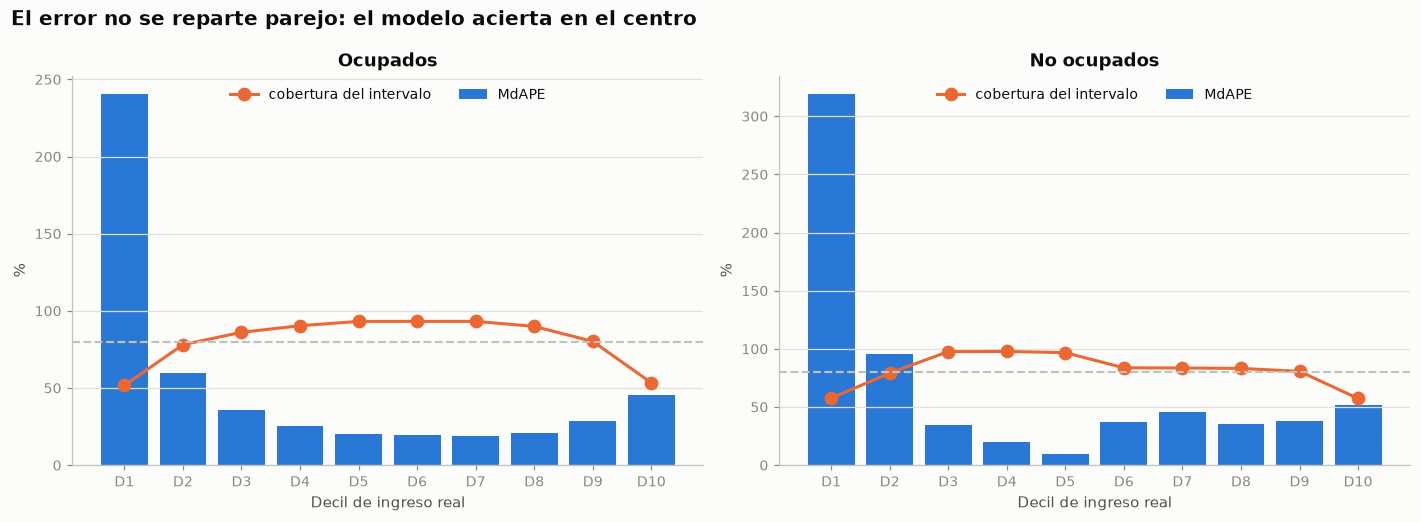

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, seg in zip(axes, SEGMENTOS):
    d = datos[seg]; te = np.where(d["te"])[0]
    t = pd.DataFrame({"pred": d["pred_test"], "real": d["y_pesos"][te], "w": d["w"][te],
                      "lo": d["lo_test"], "hi": d["hi_test"]})
    t["decil"] = pd.qcut(t["real"], 10, labels=False, duplicates="drop")
    g = t.groupby("decil")
    x = np.arange(len(g))
    mdape = np.array([wq(np.abs(s["real"] - s["pred"]) / s["real"], .5, s["w"]) * 100 for _, s in g])
    cob = np.array([np.average((s["real"] >= s["lo"]) & (s["real"] <= s["hi"]),
                               weights=s["w"]) * 100 for _, s in g])
    ax.bar(x, mdape, color=SERIES[0], label="MdAPE")
    ax.plot(x, cob, color=SERIES[1], marker="o", label="cobertura del intervalo")
    ax.axhline(COBERTURA_OBJETIVO * 100, color=AXIS, linestyle="--", linewidth=1.4)
    ax.set_xticks(x); ax.set_xticklabels([f"D{i + 1}" for i in x])
    ax.set_xlabel("Decil de ingreso real"); ax.set_ylabel("%")
    ax.set_title(seg)
    ax.legend(loc="upper center", ncols=2)
fig.suptitle("El error no se reparte parejo: el modelo acierta en el centro", x=0.01, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "04_error_por_decil")

for seg in SEGMENTOS:
    d = datos[seg]; te = np.where(d["te"])[0]
    r, p = d["y_pesos"][te], d["pred_test"]
    print(f"{seg:<12} D1 vs D10 — sesgo mediano: "
          f"{np.median(p[r <= np.quantile(r, .1)] / r[r <= np.quantile(r, .1)]):.2f}x arriba en el decil 1, "
          f"{np.median(p[r >= np.quantile(r, .9)] / r[r >= np.quantile(r, .9)]):.2f}x en el decil 10")

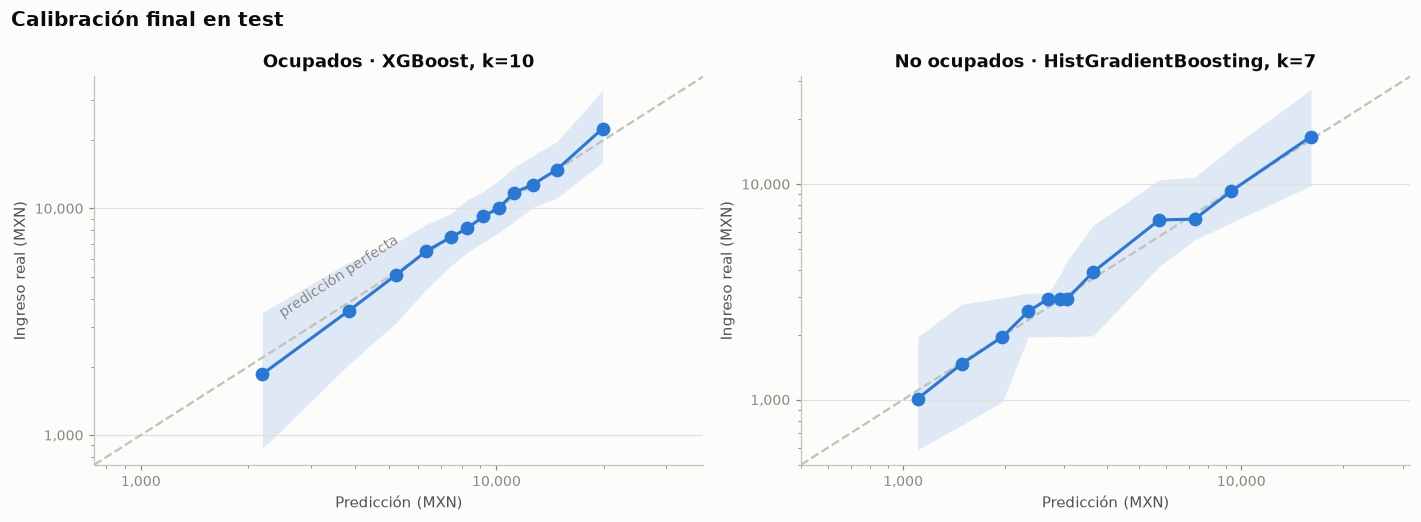

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, seg in zip(axes, SEGMENTOS):
    d = datos[seg]; te = np.where(d["te"])[0]
    t = pd.DataFrame({"pred": d["pred_test"], "real": d["y_pesos"][te], "w": d["w"][te]})
    t["g"] = pd.qcut(t["pred"], 12, labels=False, duplicates="drop")
    g = t.groupby("g")
    x = np.array([wq(s["pred"], .5, s["w"]) for _, s in g])
    y = np.array([wq(s["real"], .5, s["w"]) for _, s in g])
    lo = np.array([wq(s["real"], .25, s["w"]) for _, s in g])
    hi = np.array([wq(s["real"], .75, s["w"]) for _, s in g])
    lim = [min(x.min(), lo.min()) * .85, max(x.max(), hi.max()) * 1.15]
    ax.plot(lim, lim, color=AXIS, linestyle="--", linewidth=1.5)
    ax.fill_between(x, lo, hi, color=SERIES[0], alpha=.14, linewidth=0)
    ax.plot(x, y, color=SERIES[0], marker="o")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.xaxis.set_major_formatter(FMT_MILES); ax.yaxis.set_major_formatter(FMT_MILES)
    ax.set_xlabel("Predicción (MXN)"); ax.set_ylabel("Ingreso real (MXN)")
    ax.set_title(f"{seg} · {finales[seg]['familia']}, k={len(FEATURES[seg])}")
axes[0].annotate("predicción perfecta", (.30, .38), xycoords="axes fraction",
                 color=MUTED, fontsize=9, rotation=33)
fig.suptitle("Calibración final en test", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "04_calibracion_final");

---
## 10. Export

What ships is not "the model" — it is a bundle: the fitted pipelines for the three quantiles, the conformal
factor, and the **feature contract** (name, type, allowed values, and the exact question the form asks).

The contract is the part people forget. A model whose inputs are described only by a column order will be
served wrong within a month; one that carries its own list of accepted categories can validate its input and
fail loudly.

**One deployment caveat, stated now rather than discovered later:** the pipelines contain `ACategorias`,
a class defined in this notebook. `joblib.load` in a fresh process resolves it by import path, so loading
the bundle from a service will fail with `Can't get attribute 'ACategorias' on __main__` until that class
lives in an importable module — `src/preprocessing.py` or equivalent. Move it there before the first
deployment; the smoke test below passes only because this kernel still has the definition.


In [21]:
def contrato_features(seg):
    d = datos[seg]
    Xtr = d["X"].loc[d["tr"]]
    preguntas = {f["variable"]: f["pregunta"] for f in CONTRATO[seg]["formulario"]}
    filas = []
    for c in FEATURES[seg]:
        if c in d["cat"]:
            filas.append({"variable": c, "tipo": "categórica",
                          "valores": sorted(Xtr[c].dropna().astype(str).unique().tolist()),
                          "pregunta": preguntas.get(c, "")})
        else:
            filas.append({"variable": c, "tipo": "numérica",
                          "min": float(np.nanmin(Xtr[c])), "max": float(np.nanmax(Xtr[c])),
                          "mediana": float(np.nanmedian(Xtr[c])),
                          "acepta_nulos": bool(Xtr[c].isna().any()),
                          "pregunta": preguntas.get(c, "")})
    return filas


bundles = {}
for seg in SEGMENTOS:
    slug = "ocupados" if seg == "Ocupados" else "no_ocupados"
    bundle = {
        "segmento": seg,
        "ruteo": CONTRATO[seg]["ruteo"],
        "familia": finales[seg]["familia"],
        "hiperparametros": {k.replace("modelo__", ""): v for k, v in finales[seg]["params"].items()},
        "entrenado_ponderado": bool(PONDERAR[seg]),
        "features": FEATURES[seg],
        "contrato": contrato_features(seg),
        "target": {"columna": TARGET, "transformacion": "log",
                   "objetivo": "quantile", "retransformacion": "exp(), sin smearing",
                   "interpretacion": "q50 = mediana condicional del ingreso mensual en MXN de ago-2024"},
        "cuantiles": {str(a): modelos_q[(seg, a)] for a in ALFAS},
        "factor_conformal": factor_conformal[seg],
        "cobertura_objetivo": COBERTURA_OBJETIVO,
        "metricas_test": resultados[seg],
        "baseline_test": BASELINE[seg]["te"],
        "split": "data/processed/split_upm_3way.csv",
        "version": "v1",
    }
    joblib.dump(bundle, MODEL_DIR / f"modelo_{slug}_v1.joblib", compress=3)
    meta = {k: v for k, v in bundle.items() if k != "cuantiles"}
    (MODEL_DIR / f"modelo_{slug}_v1.json").write_text(
        json.dumps(meta, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    bundles[seg] = bundle
    mb = (MODEL_DIR / f"modelo_{slug}_v1.joblib").stat().st_size / 1e6
    print(f"OK  modelo_{slug}_v1.joblib  ({mb:.1f} MB)  + .json con el contrato")

OK  modelo_ocupados_v1.joblib  (19.5 MB)  + .json con el contrato
OK  modelo_no_ocupados_v1.joblib  (0.3 MB)  + .json con el contrato


In [22]:
# Prueba de humo: recargar el bundle y predecir como lo haría el servicio
for seg in SEGMENTOS:
    slug = "ocupados" if seg == "Ocupados" else "no_ocupados"
    b = joblib.load(MODEL_DIR / f"modelo_{slug}_v1.joblib")
    d = datos[seg]
    fila = d["X"].iloc[[np.where(d["te"])[0][0]]]
    lo = np.exp(b["cuantiles"]["0.1"].predict(fila))[0]
    mid = np.exp(b["cuantiles"]["0.5"].predict(fila))[0]
    hi = np.exp(b["cuantiles"]["0.9"].predict(fila))[0]
    f = b["factor_conformal"]
    lo_c = np.exp(np.log(mid) - f * (np.log(mid) - np.log(lo)))
    hi_c = np.exp(np.log(mid) + f * (np.log(hi) - np.log(mid)))
    print(f"{seg:<12} entre ${lo_c:,.0f} y ${hi_c:,.0f}, típicamente ${mid:,.0f}  "
          f"(real ${d['y_pesos'][np.where(d['te'])[0][0]]:,.0f})")

    # el contrato rechaza lo que no reconoce
    mala = fila.copy()
    cat0 = d["cat"][0]
    mala[cat0] = "VALOR_INEXISTENTE"
    p = np.exp(b["cuantiles"]["0.5"].predict(mala))[0]
    print(f"             con {cat0}='VALOR_INEXISTENTE' → ${p:,.0f} (degrada, no truena)")

Ocupados     entre $8,022 y $20,080, típicamente $10,954  (real $26,263)
             con formalidad='VALOR_INEXISTENTE' → $10,540 (degrada, no truena)
No ocupados  entre $2,744 y $20,559, típicamente $6,592  (real $33,626)
             con actividad_no_ocupado='VALOR_INEXISTENTE' → $1,676 (degrada, no truena)


In [23]:
# Model card
tarjeta = f"""# Model card — predicción de ingreso mensual (ENIGH 2024)

**Versión** v1 · **Fuente** INEGI, ENIGH 2024 Nueva Serie · **Pesos de** agosto 2024

## Qué predice
La **mediana condicional** del ingreso corriente monetario mensual de una persona adulta en México,
junto con un intervalo del {int(COBERTURA_OBJETIVO * 100)}%. No predice el ingreso exacto de nadie.

## Dos modelos, ruteados por una pregunta
*¿Trabajaste el mes pasado?*

| | Ocupados | No ocupados |
|---|---|---|
| preguntas | {len(FEATURES['Ocupados'])} | {len(FEATURES['No ocupados'])} |
| familia | {finales['Ocupados']['familia']} | {finales['No ocupados']['familia']} |
| MdAPE (test) | {resultados['Ocupados']['MdAPE']}% | {resultados['No ocupados']['MdAPE']}% |
| dentro de ±20% | {resultados['Ocupados']['pct_20']}% | {resultados['No ocupados']['pct_20']}% |
| RMSE (test, MXN) | ${resultados['Ocupados']['RMSE']:,.0f} | ${resultados['No ocupados']['RMSE']:,.0f} |
| RMSE en log | {resultados['Ocupados']['RMSE_log']} | {resultados['No ocupados']['RMSE_log']} |
| cobertura del intervalo | {resultados['Ocupados']['cobertura_80']}% | {resultados['No ocupados']['cobertura_80']}% |
| baseline (tabla dinámica) | {BASELINE['Ocupados']['te']['MdAPE']}% | {BASELINE['No ocupados']['te']['MdAPE']}% |

## Cómo se evaluó
Partición de tres vías agrupada por `upm` (conglomerado muestral): 64% train, 16% validation, 20% test.
El test es exactamente el mismo que definió `split_upm.csv` en la selección de variables; validation se
recortó de train para no moverlo. Hiperparámetros y calibración del intervalo se eligieron contra
validation; el test se abrió una sola vez. Todas las métricas están ponderadas por `factor`.

El **RMSE en pesos** es alto por construcción: eleva al cuadrado errores de una distribución con cola
larga, así que lo dominan unas decenas de casos del extremo alto. Se reporta como diagnóstico de cola,
no como métrica de producto; la métrica de producto es el MdAPE junto con la cobertura del intervalo.

## Limitaciones
- **El error no se reparte parejo.** El modelo acierta en el centro de la distribución y falla en los
  extremos: sobreestima el decil más bajo y subestima el más alto. Es el comportamiento esperado de un
  estimador de mediana y la razón de publicar un intervalo.
- **Universo**: adultos de 18+ con ingreso monetario positivo. No cubre a quien no percibe ingreso.
- **Corte temporal**: refleja el mercado laboral de 2024. El ingreso nominal se mueve con la inflación y
  con el salario mínimo; el modelo no se actualiza solo.
- **No es una tasación individual.** Un intervalo con razón superior/inferior de ~3x no sirve para decidir
  un crédito ni un sueldo concreto; sirve para ubicar a alguien en la distribución.
- **Sesgos de la fuente**: el ingreso se autorreporta y en encuestas de hogares se subdeclara,
  especialmente en la parte alta.

## Qué NO usa
Ninguna variable de ingreso o gasto del hogar, ni activos del hogar. El detalle está en
`seleccion_v3.json`.
"""
(MODEL_DIR / "MODEL_CARD.md").write_text(tarjeta, encoding="utf-8")
print(tarjeta)

# Model card — predicción de ingreso mensual (ENIGH 2024)

**Versión** v1 · **Fuente** INEGI, ENIGH 2024 Nueva Serie · **Pesos de** agosto 2024

## Qué predice
La **mediana condicional** del ingreso corriente monetario mensual de una persona adulta en México,
junto con un intervalo del 80%. No predice el ingreso exacto de nadie.

## Dos modelos, ruteados por una pregunta
*¿Trabajaste el mes pasado?*

| | Ocupados | No ocupados |
|---|---|---|
| preguntas | 10 | 7 |
| familia | XGBoost | HistGradientBoosting |
| MdAPE (test) | 30.78% | 41.03% |
| dentro de ±20% | 34.35% | 26.18% |
| RMSE (test, MXN) | $13,105 | $9,734 |
| RMSE en log | 0.7046 | 0.8609 |
| cobertura del intervalo | 80.64% | 81.34% |
| baseline (tabla dinámica) | 38.57% | 59.61% |

## Cómo se evaluó
Partición de tres vías agrupada por `upm` (conglomerado muestral): 64% train, 16% validation, 20% test.
El test es exactamente el mismo que definió `split_upm.csv` en la selección de variables; validation se
recortó de train p

---
## 11. Ranked summary of every model evaluated

Everything that was ever scored — the baseline, the ten screened families, the tuned variants, the weighted
and unweighted versions, and the final quantile model — went into one log as it happened. Two rankings come
out of it, and they are kept apart on purpose:

- **On validation**, where every model was measured, so the comparison is like for like. This is the
  ranking that answers "which model was best".
- **On test**, which only the finalists and the two reference points ever touched. These are the numbers to
  quote, and there are deliberately few of them: a leaderboard computed on the holdout would turn it into a
  validation set.

Read both against `rango_cv_pp` from §6.1. Gaps smaller than that are noise, and on this problem most of
the gaps between boosting families are.


In [24]:
ranking = pd.DataFrame(REGISTRO)
ORDEN_COLS = ["segmento", "modelo", "etapa", "k", "MdAPE", "pct_20", "MdAE", "MAE",
              "RMSE", "RMSE_log", "R2_log", "cobertura_80", "segundos"]
ranking = ranking[[c for c in ORDEN_COLS if c in ranking.columns] +
                  [c for c in ranking.columns if c not in ORDEN_COLS and c != "conjunto"]
                  ].assign(conjunto=ranking["conjunto"])

tabla_val = (ranking[ranking.conjunto == "validation"]
             .sort_values(["segmento", "MdAPE"])
             .drop(columns=["conjunto", "cobertura_80"], errors="ignore")
             .reset_index(drop=True))
tabla_val.insert(0, "#", tabla_val.groupby("segmento").cumcount() + 1)

print("=" * 96)
print("RANKING EN VALIDATION — todos los modelos, mejor a peor por MdAPE")
print("=" * 96)
display(tabla_val)

RANKING EN VALIDATION — todos los modelos, mejor a peor por MdAPE


,#,segmento,modelo,etapa,k,MdAPE,pct_20,MdAE,MAE,RMSE,RMSE_log,R2_log,segundos,ancho_mediano,razon_sup_inf
0,1,No ocupados,HistGradientBoosting,tamizaje (defaults),7,41.450,26.310,"1,422.000","3,394.000","8,440.000",0.874,0.462,0.400,NaN,NaN
1,2,No ocupados,HistGradientBoosting,tuneado (random),7,41.560,25.450,"1,427.000","3,379.000","8,429.000",0.874,0.462,34.000,NaN,NaN
2,3,No ocupados,HistGradientBoosting,tuneado (random+grid),7,41.560,25.450,"1,427.000","3,379.000","8,429.000",0.874,0.462,3.000,NaN,NaN
3,4,No ocupados,HistGradientBoosting · q50 (final),cuantil,7,41.560,25.450,"1,427.000","3,379.000","8,429.000",0.874,0.462,NaN,NaN,NaN
4,5,No ocupados,LightGBM,tuneado (random),7,41.810,25.990,"1,400.000","3,368.000","8,399.000",0.871,0.466,58.000,NaN,NaN
5,6,No ocupados,LightGBM,tamizaje (defaults),7,41.920,26.430,"1,419.000","3,399.000","8,457.000",0.875,0.461,0.600,NaN,NaN
6,7,No ocupados,HistGradientBoosting · ponderado por factor,tuneado (random+grid),7,41.940,26.480,"1,466.000","3,390.000","8,440.000",0.876,0.460,NaN,NaN,NaN
7,8,No ocupados,XGBoost,tamizaje (defaults),7,42.270,25.840,"1,426.000","3,401.000","8,442.000",0.873,0.464,1.600,NaN,NaN
8,9,No ocupados,Extra Trees,tamizaje (defaults),7,42.390,24.260,"1,498.000","3,444.000","8,453.000",0.873,0.463,0.600,NaN,NaN
9,10,No ocupados,Random Forest,tamizaje (defaults),7,42.750,25.390,"1,491.000","3,438.000","8,468.000",0.875,0.462,0.800,NaN,NaN


In [25]:
tabla_test = (ranking[ranking.conjunto == "test"]
              .sort_values(["segmento", "MdAPE"])
              .drop(columns=["conjunto"], errors="ignore")
              .reset_index(drop=True))
tabla_test.insert(0, "#", tabla_test.groupby("segmento").cumcount() + 1)

print("=" * 96)
print("RANKING EN TEST (holdout) — sólo finalistas y referencias")
print("=" * 96)
display(tabla_test)

REPORTES = PROJECT_ROOT / "reports"
REPORTES.mkdir(parents=True, exist_ok=True)
ranking.to_csv(REPORTES / "ranking_modelos.csv", index=False, encoding="utf-8")
tabla_val.to_csv(REPORTES / "ranking_validation.csv", index=False, encoding="utf-8")
tabla_test.to_csv(REPORTES / "ranking_test.csv", index=False, encoding="utf-8")
print(f"\nOK  reports/ranking_modelos.csv  ({len(ranking)} evaluaciones registradas)")
print("OK  reports/ranking_validation.csv · reports/ranking_test.csv")

RANKING EN TEST (holdout) — sólo finalistas y referencias


,#,segmento,modelo,etapa,k,MdAPE,pct_20,MdAE,MAE,RMSE,RMSE_log,R2_log,cobertura_80,segundos,ancho_mediano,razon_sup_inf
0,1,No ocupados,HistGradientBoosting · q50 (final),final,7,41.030,26.180,"1,413.000","3,586.000","9,734.000",0.861,0.497,81.340,NaN,"7,027.000",6.040
1,2,No ocupados,Notebook 03 (LightGBM sin tunear),referencia,7,41.620,25.580,"1,416.000",NaN,NaN,NaN,0.499,NaN,NaN,NaN,NaN
2,3,No ocupados,Baseline (tabla dinámica),baseline,2,59.610,16.470,"2,406.000","4,856.000","11,066.000",1.157,0.092,NaN,0.000,NaN,NaN
3,1,Ocupados,XGBoost · q50 (final),final,10,30.780,34.350,"2,437.000","4,748.000","13,105.000",0.705,0.515,80.640,NaN,"10,857.000",3.620
4,2,Ocupados,Notebook 03 (LightGBM sin tunear),referencia,10,30.840,34.320,"2,479.000",NaN,NaN,NaN,0.521,NaN,NaN,NaN,NaN
5,3,Ocupados,Baseline (tabla dinámica),baseline,2,38.570,27.750,"3,450.000","5,854.000","14,227.000",0.902,0.206,NaN,0.000,NaN,NaN



OK  reports/ranking_modelos.csv  (38 evaluaciones registradas)
OK  reports/ranking_validation.csv · reports/ranking_test.csv


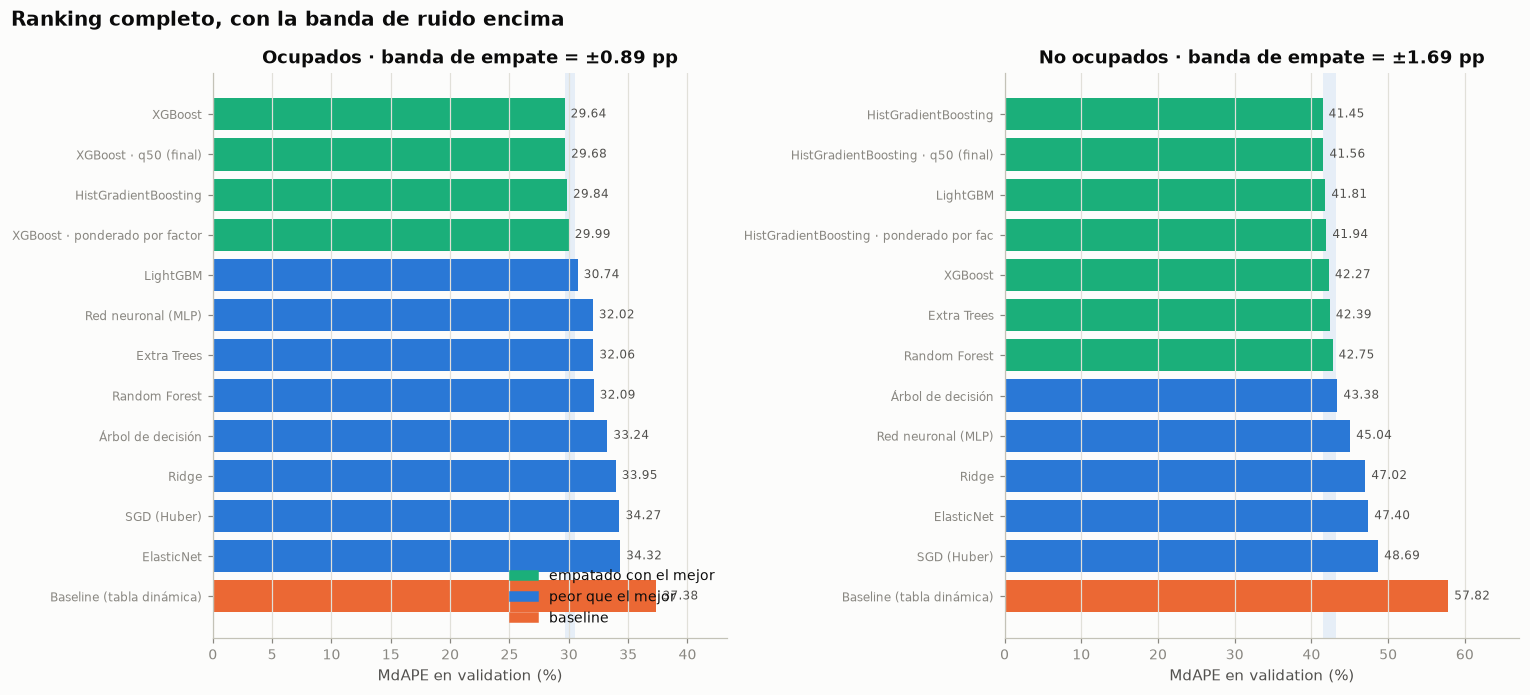

In [26]:
# El ranking, con la banda de ruido de §6.1 encima: lo que cae dentro está empatado
ruido_df = pd.DataFrame(ruido).set_index("segmento")

fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))
for ax, seg in zip(axes, SEGMENTOS):
    t = (tabla_val[tabla_val.segmento == seg]
         .drop_duplicates("modelo", keep="first")
         .sort_values("MdAPE", ascending=False))
    mejor = t["MdAPE"].min()
    banda = ruido_df.loc[seg, "rango_cv_pp"]
    ax.axvspan(mejor, mejor + banda, color=SERIES[0], alpha=.10, linewidth=0)
    colores = [SERIES[2] if v <= mejor + banda else SERIES[0] for v in t["MdAPE"]]
    colores = [SERIES[1] if "Baseline" in m else c for m, c in zip(t["modelo"], colores)]
    ax.barh(np.arange(len(t)), t["MdAPE"], color=colores)
    ax.set_yticks(np.arange(len(t)))
    ax.set_yticklabels([m[:40] for m in t["modelo"]], fontsize=8)
    for i, v in enumerate(t["MdAPE"]):
        ax.annotate(f"{v:.2f}", (v, i), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8, color=INK2)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, t["MdAPE"].max() * 1.16)
    ax.set_xlabel("MdAPE en validation (%)")
    ax.set_title(f"{seg} · banda de empate = ±{banda:.2f} pp")
axes[0].legend(handles=[Patch(color=SERIES[2], label="empatado con el mejor"),
                        Patch(color=SERIES[0], label="peor que el mejor"),
                        Patch(color=SERIES[1], label="baseline")], loc="lower right")
fig.suptitle("Ranking completo, con la banda de ruido encima", x=0.01, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
guardar(fig, "04_ranking");

---
## Summary

Two model bundles in `models/`, each carrying its fitted pipelines, its conformal factor, its feature
contract and its questions. `MODEL_CARD.md` states what the thing does and where it fails.

**Honest reading of the result.** Compare the three rows in §9: the pivot-table baseline, notebook 03's
untuned LightGBM, and the tuned final model. If the gap between the last two is small, that is not a failure
of the tuning — it is the data telling you that ten self-reported characteristics explain about as much of
Mexican income as they are ever going to, and that the next real gain comes from a better question, not a
better optimiser.

**Before this is a product**

1. The interval is the deliverable. Ship "between X and Y"; a point estimate at ~31% median error will be
   read as a promise.
2. Add a percentile position — *"you earn more than N% of people with your profile"* — which is robust even
   where the point estimate is not.
3. Monitor the input distribution. The model degrades silently if the people using the form stop looking
   like ENIGH's sample, and the contract in each bundle is what makes that checkable.
4. Re-fit when ENIGH 2026 lands. The pipeline is reproducible end to end: notebooks 01 → 04.
